# Medical Appointment No-Show Analysis Using Python

This project analyzes medical appointment data to understand factors associated with patients missing their scheduled appointments.

## 1. Import Libraries

In this section, the required Python libraries are imported for data analysis and visualization.

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

The dataset is loaded from a CSV file into a Pandas DataFrame.

In [83]:
df = pd.read_csv(
    r"C:\Users\m-m-1\OneDrive\מסמכים\Medical_Appointment_No_Show_Analysis\KaggleV2-May-2016.csv"
)

In [24]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


The first five rows show the structure of the dataset, including patient information, appointment dates, medical conditions, SMS reminders, and no-show status.

## 3. Data Understanding

Before cleaning the dataset, we explore its structure, dimensions, and summary statistics.

In [25]:
df.shape

(110527, 14)

### Dataset Dimensions

The dataset contains rows representing appointments and columns representing patient and appointment information.

In [26]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Insight:

The summary statistics revealed potential data quality issues in the Age column, including negative ages and ages greater than 100 years.

### Detect Invalid Ages

Checking for unrealistic age values.

In [27]:
df[df["Age"]<0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


Finding:

One record contains a negative age value (-1), which is not realistic and requires cleaning.

### Detect Extreme Age Values

Checking for age values above 100 years.

In [28]:
df[df["Age"]>100]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
58014,9.762948e+14,5651757,F,2016-05-03T09:14:53Z,2016-05-03T00:00:00Z,102,CONQUISTA,0,0,0,0,0,0,No
63912,3.196321e+13,5700278,F,2016-05-16T09:17:44Z,2016-05-19T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
63915,3.196321e+13,5700279,F,2016-05-16T09:17:44Z,2016-05-19T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
68127,3.196321e+13,5562812,F,2016-04-08T14:29:17Z,2016-05-16T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,Yes
76284,3.196321e+13,5744037,F,2016-05-30T09:44:51Z,2016-05-30T00:00:00Z,115,ANDORINHAS,0,0,0,0,1,0,No
90372,2.342836e+11,5751563,F,2016-05-31T10:19:49Z,2016-06-02T00:00:00Z,102,MARIA ORTIZ,0,0,0,0,0,0,No
97666,7.482346e+14,5717451,F,2016-05-19T07:57:56Z,2016-06-03T00:00:00Z,115,SÃO JOSÉ,0,1,0,0,0,1,No


Finding:

A small number of records contain age values above 100 years. These observations require further review before analysis.

Insight:

The summary statistics revealed potential data quality issues in the Age column, including negative ages and ages greater than 100 years.

## 4. Data Cleaning

### Remove Invalid Age Values

In [86]:
df_clean = df[(df["Age"] >= 0) & (df["Age"] <= 100)]


### Missing Values Check

In [36]:
df_clean.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

Finding:

No missing values were detected in the cleaned dataset.

In [87]:
df_clean.shape

(110519, 14)

Finding:

After removing unrealistic age values, the dataset contains 110,519 valid records.

### Duplicate Records Check

In [37]:
df_clean.duplicated().sum()

np.int64(0)

Finding:

No duplicate records were found in the cleaned dataset.

## 5. Exploratory Data Analysis (EDA)

In [38]:
df_clean["No-show"].value_counts()

No-show
No     88203
Yes    22316
Name: count, dtype: int64

In [45]:
((df_clean["No-show"].value_counts(normalize=True) * 100)
 .round(2)
 .astype(str) + "%")

No-show
No     79.81%
Yes    20.19%
Name: proportion, dtype: object

### Overall No-Show Distribution

Insight:

Approximately 20.2% of appointments resulted in a no-show, while 79.8% of patients attended their scheduled appointments.

This indicates that missed appointments represent a significant operational challenge for healthcare providers.

### SMS Reminder vs No-Show

In [46]:
df_clean.groupby("SMS_received")["No-show"].value_counts()

SMS_received  No-show
0             No         62506
              Yes        12532
1             No         25697
              Yes         9784
Name: count, dtype: int64

In [49]:
pd.crosstab(
    df_clean["SMS_received"],
    df_clean["No-show"],
    normalize="index"
) * 100

No-show,No,Yes
SMS_received,,
0,83.299128,16.700872
1,72.424678,27.575322


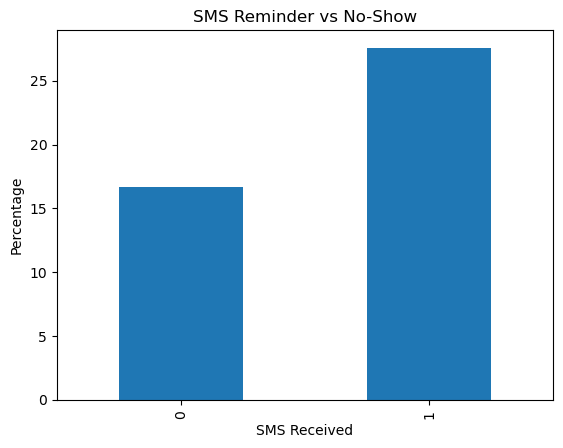

In [91]:
sms_no_show = pd.crosstab(
    df_clean["SMS_received"],
    df_clean["No-show"],
    normalize="index"
) * 100

sms_no_show["Yes"].plot(kind="bar")

plt.title("SMS Reminder vs No-Show")
plt.ylabel("Percentage")
plt.xlabel("SMS Received")
plt.show()

Insight:
Patients who received SMS reminders showed a higher no-show rate (27.6%) compared to patients who did not receive SMS reminders (16.7%). Further investigation is required to determine whether this relationship is causal or influenced by other factors.

### Age Group vs No-Show

In [90]:
df_clean = df_clean.copy()

df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[0,18,35,50,65,100],
    labels=["0-18","19-35","36-50","51-65","66+"]
)

In [60]:
pd.crosstab(
    df_clean["Age_Group"],
    df_clean["No-show"],
    normalize="index"
) * 100

No-show,No,Yes
Age_Group,,
0-18,77.462787,22.537213
19-35,76.165224,23.834776
36-50,79.674208,20.325792
51-65,83.450863,16.549137
66+,84.481721,15.518279


Insight:

Patients aged 19-35 showed the highest no-show rate (23.8%), while patients aged 66+ had the lowest no-show rate (15.5%). This suggests that younger adults are more likely to miss medical appointments compared to older patients.

In [68]:
import matplotlib.pyplot as plt

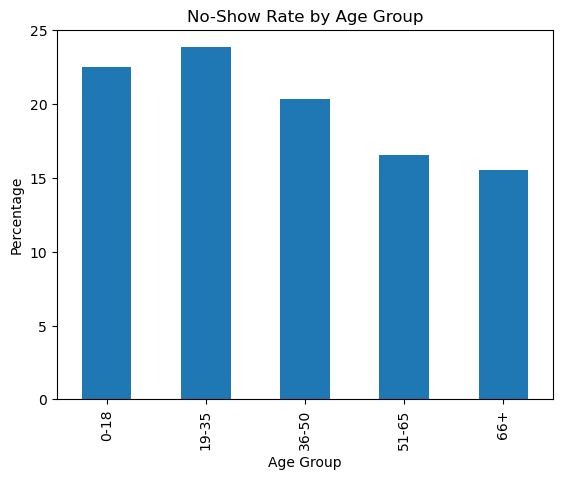

In [70]:
age_no_show = pd.crosstab(
    df_clean["Age_Group"],
    df_clean["No-show"],
    normalize="index"
) * 100

age_no_show["Yes"].plot(kind="bar")

plt.title("No-Show Rate by Age Group")
plt.ylabel("Percentage")
plt.xlabel("Age Group")

plt.show()


In [72]:
pd.crosstab(
    df_clean["Gender"],
    df_clean["No-show"],
    normalize="index"
) * 100

No-show,No,Yes
Gender,,
F,79.687326,20.312674
M,80.032052,19.967948


Female patients showed a slightly higher no-show rate (20.3%)
compared to male patients (20.0%).

However, the difference is minimal, suggesting that gender
is not a strong predictor of appointment attendance.

In [75]:
pd.crosstab(
    df_clean["Diabetes"],
    df_clean["No-show"],
    normalize="index"
) * 100

No-show,No,Yes
Diabetes,,
0,79.638512,20.361488
1,81.996727,18.003273


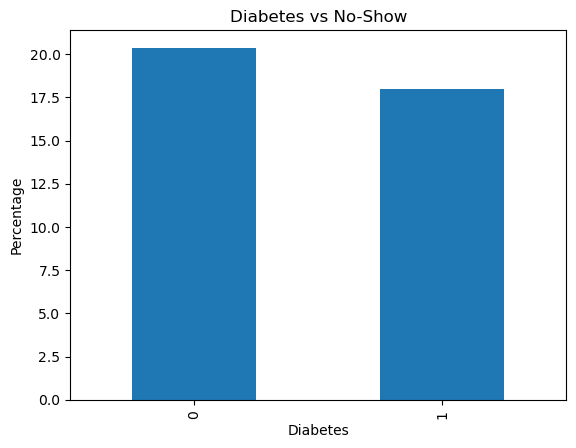

In [92]:
diabetes_no_show = pd.crosstab(
    df_clean["Diabetes"],
    df_clean["No-show"],
    normalize="index"
) * 100

diabetes_no_show["Yes"].plot(kind="bar")

plt.title("Diabetes vs No-Show")
plt.ylabel("Percentage")
plt.xlabel("Diabetes")
plt.show()

Patients with diabetes showed a lower no-show rate (18.0%)
compared to patients without diabetes (20.4%).

This suggests that diabetic patients may be more engaged
with their healthcare and more likely to attend scheduled appointments.

In [79]:
pd.crosstab(
    df_clean["Hipertension"],
    df_clean["No-show"],
    normalize="index"
) *100

No-show,No,Yes
Hipertension,,
0,79.098051,20.901949
1,82.697248,17.302752


Patients with hypertension showed a lower no-show rate (17.3%)
compared to patients without hypertension (20.9%).

This may indicate that patients with chronic conditions are
more engaged with healthcare services and more likely to attend appointments.

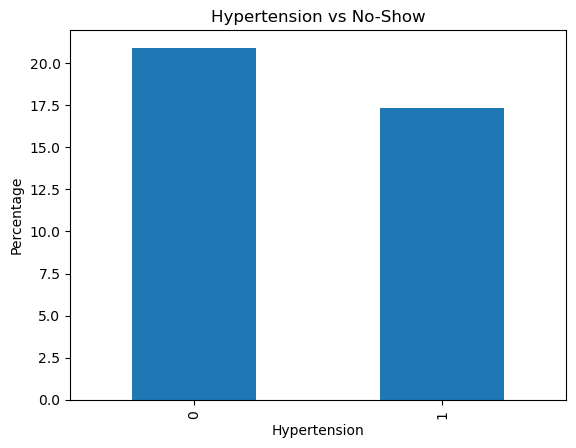

In [94]:
hyper_no_show = pd.crosstab(
    df_clean["Hipertension"],
    df_clean["No-show"],
    normalize="index"
) * 100

hyper_no_show["Yes"].plot(kind="bar")

plt.title("Hypertension vs No-Show")
plt.ylabel("Percentage")
plt.xlabel("Hypertension")
plt.show()

In [80]:
pd.crosstab(
    df_clean["Scholarship"],
    df_clean["No-show"],
    normalize="index"
) * 100


No-show,No,Yes
Scholarship,,
0,80.194264,19.805736
1,76.263696,23.736304


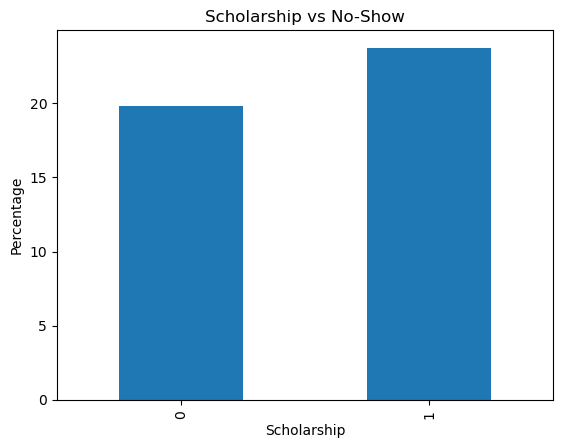

In [95]:
scholarship_no_show = pd.crosstab(
    df_clean["Scholarship"],
    df_clean["No-show"],
    normalize="index"
) * 100

scholarship_no_show["Yes"].plot(kind="bar")

plt.title("Scholarship vs No-Show")
plt.ylabel("Percentage")
plt.xlabel("Scholarship")
plt.show()

Patients receiving scholarships showed a higher no-show rate (23.7%)
compared to patients without scholarships (19.8%).

This may suggest that socioeconomic factors influence
appointment attendance and should be considered when designing
patient engagement strategies.

### Summary of Insights

| Variable     | Result             |
| ------------ | ------------------ |
| SMS          | Higher No-show     |
| Age          | 19-35 Highest      |
| Gender       | Minimal Difference |
| Diabetes     | Lower No-show      |
| Hypertension | Lower No-show      |
| Scholarship  | Higher No-show     |


### 6. Final Conclusions & Recommendations

Key Findings

1. Approximately 20% of appointments resulted in a no-show.

2. Patients aged 19–35 had the highest no-show rate, while patients aged 66+ had the lowest.

3. Receiving SMS reminders was associated with a higher no-show rate, suggesting that additional factors may influence attendance behavior.

4. Patients with diabetes and hypertension showed lower no-show rates compared to patients without these conditions.

5. Patients receiving scholarships showed a higher no-show rate, indicating that socioeconomic factors may affect appointment attendance.

Business Recommendation

Healthcare providers should focus on younger adults and patients with higher no-show risk by implementing targeted reminder strategies and improving patient engagement.

Recommendations

1. Target younger patients (19–35 years) with reminder campaigns.
2. Review the effectiveness of SMS reminders, as patients receiving SMS showed higher no-show rates.
3. Provide additional follow-up for patients receiving scholarships.
4. Continue engagement strategies for chronic disease patients, as they showed better attendance rates.